# 13. 시스템 통합: 시각 AI 웹 서비스 완료 · 피드백 반영 · 센서·영상 통합 테스트

## 학습 목표
1. Vision + Sensor + LLM 모듈을 **웹 서비스 API**로 통합한다.
2. 운영자 **피드백 루프**를 구현하고 임계값/가중치에 반영한다.
3. 센서·영상 **End-to-End 통합 테스트**로 인수 기준을 검증한다.

---

## 통합 범위

```text
[이미지] ──┐
           ├─> [VisionModule] ─┐
[센서 CSV]─┘                   ├─> [FusionService] ─> [LLM] ─> [API Response]
                               │
                    [Feedback Store] ←── 운영자 피드백
                               │
                    [Threshold/Weight Update]
```

선행 노트북: `11`(핵심 모듈), `12`(LLM 연동)

In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import Any
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "system_integration"
FEEDBACK_DIR = OUT_DIR / "feedback"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FEEDBACK_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("OUT_DIR:", OUT_DIR)

PROJECT_ROOT: C:\MyCursorLab\10_프로젝트
DATA_ROOT exists: True
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\system_integration


## 1) 통합 서비스 코어 모듈 (웹 서비스용 경량 버전)

11번 모듈을 서비스 레이어에서 바로 호출할 수 있도록 재구성합니다.

In [2]:
@dataclass
class ServiceConfig:
    """운영 중 피드백으로 갱신되는 설정."""
    w_vision: float = 0.6
    w_sensor: float = 0.4
    risk_high: float = 0.75
    risk_medium: float = 0.45
    conf_human_review: float = 0.40

    def to_dict(self) -> dict:
        return asdict(self)

    @classmethod
    def load(cls, path: Path) -> "ServiceConfig":
        if path.exists():
            return cls(**json.loads(path.read_text(encoding="utf-8")))
        return cls()

    def save(self, path: Path):
        path.write_text(json.dumps(self.to_dict(), indent=2), encoding="utf-8")


CONFIG_PATH = OUT_DIR / "service_config.json"
config = ServiceConfig.load(CONFIG_PATH)
config.save(CONFIG_PATH)
print("현재 서비스 설정:", config.to_dict())


class VisionModule:
    def run(self, gray: np.ndarray) -> dict:
        mean, std = float(gray.mean()), float(gray.std())
        gx, gy = np.diff(gray, axis=1), np.diff(gray, axis=0)
        grad = float((gx**2).mean() + (gy**2).mean())
        edge = float((np.abs(gx) > 0.08).mean())
        feats = {"img_mean": mean, "img_std": std, "grad_energy": grad, "edge_ratio": edge}
        risk = float(np.clip(
            0.25 * min(1, grad / 0.03) + 0.35 * min(1, edge / 0.25) + 0.40 * min(1, abs(mean - 0.5) / 0.35),
            0, 1,
        ))
        return {"vision_features": feats, "vision_risk_score": risk}


class SensorModule:
    def run(self, df: pd.DataFrame, recent_window: int = 30) -> dict:
        x = df.copy()
        for c in ["lux", "temp", "vibration"]:
            x[c] = x[c].interpolate().bfill().ffill()
            # 이상치 clip은 약하게(k=3) — 실제 이상 신호를 과도하게 지우지 않음
            q1, q3 = x[c].quantile(0.25), x[c].quantile(0.75)
            iqr = q3 - q1
            x[c] = x[c].clip(q1 - 3.0 * iqr, q3 + 3.0 * iqr)
            x[f"{c}_z"] = (x[c] - x[c].mean()) / (x[c].std() + 1e-9)

        # 최근 윈도우의 |z| 최대값으로 리스크 계산 (끝 시점만 보면 중간 이상을 놓침)
        recent = x.tail(min(recent_window, len(x)))
        vib_z = float(recent["vibration_z"].abs().max())
        lux_z = float(recent["lux_z"].abs().max())
        temp_z = float(recent["temp_z"].abs().max())

        last = x.iloc[-1]
        risk = float(np.clip(
            0.45 * min(1, vib_z / 3)
            + 0.30 * min(1, lux_z / 3)
            + 0.25 * min(1, temp_z / 3),
            0, 1,
        ))
        feats = {
            "lux": float(last["lux"]), "temp": float(last["temp"]), "vibration": float(last["vibration"]),
            "lux_z": lux_z, "temp_z": temp_z, "vibration_z": vib_z,
        }
        return {"sensor_features_last": feats, "sensor_risk_score": risk, "sensor_table": x}


class FusionService:
    def __init__(self, cfg: ServiceConfig):
        self.cfg = cfg

    def risk_level(self, score: float) -> str:
        if score >= self.cfg.risk_high:
            return "HIGH"
        if score >= self.cfg.risk_medium:
            return "MEDIUM"
        return "LOW"

    def run(self, vision_out: dict, sensor_out: dict) -> dict:
        v, s = vision_out["vision_risk_score"], sensor_out["sensor_risk_score"]
        fused = self.cfg.w_vision * v + self.cfg.w_sensor * s
        return {
            "vision_risk_score": float(v),
            "sensor_risk_score": float(s),
            "fused_risk_score": float(np.clip(fused, 0, 1)),
            "risk_level": self.risk_level(float(fused)),
            "vision_features": vision_out["vision_features"],
            "sensor_features_last": sensor_out["sensor_features_last"],
            "config_snapshot": self.cfg.to_dict(),
        }


class MockLLM:
    def analyze(self, fusion: dict) -> dict:
        score = fusion["fused_risk_score"]
        urgency = fusion["risk_level"]
        return {
            "summary": f"통합 리스크 {score:.2f} ({urgency})",
            "recommended_actions": ["Lot 샘플링 검사", "센서 캘리브레이션 점검"],
            "urgency": urgency,
            "confidence": round(min(0.95, 0.5 + score * 0.4), 2),
        }


vision_module = VisionModule()
sensor_module = SensorModule()
fusion_service = FusionService(config)
llm = MockLLM()
print("코어 모듈 초기화 완료")

현재 서비스 설정: {'w_vision': 0.65, 'w_sensor': 0.35, 'risk_high': 0.75, 'risk_medium': 0.43, 'conf_human_review': 0.4}
코어 모듈 초기화 완료


## 2) 시각 AI 웹 서비스 통합 (API 레이어)

FastAPI 없이도 동일 계약을 검증할 수 있도록 **인프로세스 웹 서비스**를 구현합니다.
실제 배포 시 아래 메서드를 FastAPI 라우트로 옮기면 됩니다.

In [3]:
class VisualAIWebService:
    """시각 AI + 센서 통합 웹 서비스 (인프로세스)."""

    def __init__(self, vision, sensor, fusion, llm, cfg: ServiceConfig):
        self.vision = vision
        self.sensor = sensor
        self.fusion = fusion
        self.llm = llm
        self.cfg = cfg
        self.request_log: list[dict] = []

    def health(self) -> dict:
        return {
            "status": "ok",
            "service": "pcb-aoi-visual-ai",
            "version": "1.0.0",
            "config": self.cfg.to_dict(),
            "timestamp": datetime.now().isoformat(timespec="seconds"),
        }

    def analyze(self, gray_img: np.ndarray, sensor_df: pd.DataFrame, lot_id: str = "LOT-UNKNOWN") -> dict:
        t0 = time.perf_counter()
        vision_out = self.vision.run(gray_img)
        sensor_out = self.sensor.run(sensor_df)
        fusion_out = self.fusion.run(vision_out, sensor_out)
        llm_out = self.llm.analyze(fusion_out)

        needs_review = llm_out.get("confidence", 1.0) < self.cfg.conf_human_review
        latency_ms = (time.perf_counter() - t0) * 1000

        response = {
            "lot_id": lot_id,
            "status": "success",
            "fusion": {
                "vision_risk_score": fusion_out["vision_risk_score"],
                "sensor_risk_score": fusion_out["sensor_risk_score"],
                "fused_risk_score": fusion_out["fused_risk_score"],
                "risk_level": fusion_out["risk_level"],
            },
            "llm": llm_out,
            "needs_human_review": needs_review,
            "latency_ms": round(latency_ms, 2),
            "timestamp": datetime.now().isoformat(timespec="seconds"),
        }
        self.request_log.append({"lot_id": lot_id, "latency_ms": response["latency_ms"], "risk_level": fusion_out["risk_level"]})
        return response


web_service = VisualAIWebService(vision_module, sensor_module, fusion_service, llm, config)
print(json.dumps(web_service.health(), indent=2, ensure_ascii=False))

{
  "status": "ok",
  "service": "pcb-aoi-visual-ai",
  "version": "1.0.0",
  "config": {
    "w_vision": 0.65,
    "w_sensor": 0.35,
    "risk_high": 0.75,
    "risk_medium": 0.43,
    "conf_human_review": 0.4
  },
  "timestamp": "2026-07-10T14:55:35"
}


## 3) 센서·영상 샘플 입력 준비 및 단일 요청 테스트

In [4]:
def load_sample_image(split="test", index=0) -> tuple[np.ndarray, str]:
    paths = sorted((DATA_ROOT / split / "images").glob("*.jpg"))
    if not paths:
        raise FileNotFoundError("이미지 없음")
    p = paths[index]
    gray = np.array(Image.open(p).convert("L"), dtype=np.float32) / 255.0
    return gray, p.stem


def make_sensor_df(n=120, anomaly=False, seed=42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    df = pd.DataFrame({
        "t": t,
        "lux": 950 + 60 * np.sin(2 * np.pi * t / 50) + rng.normal(0, 12, n),
        "temp": 24 + 0.002 * t + rng.normal(0, 0.08, n),
        "vibration": 0.05 + np.abs(rng.normal(0, 0.01, n)),
    })
    if anomaly:
        # 최근 구간(끝부분)에 이상을 넣어 실시간 감지 시나리오와 맞춤
        start = max(0, n - 25)
        df.loc[start:, "vibration"] += 0.06
        df.loc[start:, "lux"] -= 150
        df.loc[start:, "temp"] += 1.2
    return df


gray_img, img_stem = load_sample_image(index=0)
sensor_normal = make_sensor_df(anomaly=False, seed=1)
sensor_anomaly = make_sensor_df(anomaly=True, seed=2)

resp_normal = web_service.analyze(gray_img, sensor_normal, lot_id=f"LOT-{img_stem}-N")
resp_anomaly = web_service.analyze(gray_img, sensor_anomaly, lot_id=f"LOT-{img_stem}-A")

print("=== 정상 센서 ===")
print(json.dumps(resp_normal, indent=2, ensure_ascii=False))
print("\n=== 이상 센서 ===")
print(json.dumps(resp_anomaly, indent=2, ensure_ascii=False))

=== 정상 센서 ===
{
  "lot_id": "LOT-l_light_01_missing_hole_04_2_600-N",
  "status": "success",
  "fusion": {
    "vision_risk_score": 0.2837394305190263,
    "sensor_risk_score": 0.7363407529007994,
    "fused_risk_score": 0.4421498933526468,
    "risk_level": "MEDIUM"
  },
  "llm": {
    "summary": "통합 리스크 0.44 (MEDIUM)",
    "recommended_actions": [
      "Lot 샘플링 검사",
      "센서 캘리브레이션 점검"
    ],
    "urgency": "MEDIUM",
    "confidence": 0.68
  },
  "needs_human_review": false,
  "latency_ms": 16.37,
  "timestamp": "2026-07-10T14:55:35"
}

=== 이상 센서 ===
{
  "lot_id": "LOT-l_light_01_missing_hole_04_2_600-A",
  "status": "success",
  "fusion": {
    "vision_risk_score": 0.2837394305190263,
    "sensor_risk_score": 0.6841821990816279,
    "fused_risk_score": 0.4238943995159368,
    "risk_level": "LOW"
  },
  "llm": {
    "summary": "통합 리스크 0.42 (LOW)",
    "recommended_actions": [
      "Lot 샘플링 검사",
      "센서 캘리브레이션 점검"
    ],
    "urgency": "LOW",
    "confidence": 0.67
  },
  "needs_

## 4) 피드백 반영 루프

운영자가 판정 결과를 수정하면 서비스 설정(가중치/임계값)을 갱신합니다.

In [5]:
class FeedbackStore:
    def __init__(self, path: Path):
        self.path = path
        self.records: list[dict] = []
        if path.exists():
            self.records = json.loads(path.read_text(encoding="utf-8"))

    def add(self, lot_id: str, predicted_level: str, actual_level: str, note: str = "") -> dict:
        rec = {
            "id": f"fb-{len(self.records)+1:04d}",
            "lot_id": lot_id,
            "predicted_level": predicted_level,
            "actual_level": actual_level,
            "correct": predicted_level == actual_level,
            "note": note,
            "timestamp": datetime.now().isoformat(timespec="seconds"),
        }
        self.records.append(rec)
        self.save()
        return rec

    def save(self):
        self.path.write_text(json.dumps(self.records, ensure_ascii=False, indent=2), encoding="utf-8")

    def to_df(self) -> pd.DataFrame:
        return pd.DataFrame(self.records) if self.records else pd.DataFrame()


class FeedbackReflector:
    """오판 패턴에 따라 가중치/임계값을 조정."""

    LEVEL_ORDER = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}

    def apply(self, cfg: ServiceConfig, feedback_df: pd.DataFrame) -> ServiceConfig:
        if feedback_df.empty:
            return cfg

        new_cfg = ServiceConfig(**cfg.to_dict())
        wrong = feedback_df[~feedback_df["correct"]]
        if wrong.empty:
            return new_cfg

        # 과검(예측 > 실제): vision 가중치 소폭 감소
        over = 0
        under = 0
        for _, r in wrong.iterrows():
            p = self.LEVEL_ORDER.get(r["predicted_level"], 1)
            a = self.LEVEL_ORDER.get(r["actual_level"], 1)
            if p > a:
                over += 1
            elif p < a:
                under += 1

        if over > under:
            new_cfg.w_vision = max(0.3, new_cfg.w_vision - 0.05)
            new_cfg.w_sensor = 1.0 - new_cfg.w_vision
            new_cfg.risk_medium = min(0.55, new_cfg.risk_medium + 0.02)
            print(f"피드백 반영: 과검 우세 → w_vision={new_cfg.w_vision:.2f}, risk_medium={new_cfg.risk_medium:.2f}")
        elif under > over:
            new_cfg.w_vision = min(0.8, new_cfg.w_vision + 0.05)
            new_cfg.w_sensor = 1.0 - new_cfg.w_vision
            new_cfg.risk_medium = max(0.35, new_cfg.risk_medium - 0.02)
            print(f"피드백 반영: 미검 우세 → w_vision={new_cfg.w_vision:.2f}, risk_medium={new_cfg.risk_medium:.2f}")
        else:
            print("피드백 반영: 과검/미검 균형 — 설정 유지")

        return new_cfg


fb_store = FeedbackStore(FEEDBACK_DIR / "feedback_log.json")

# 운영자 피드백 시뮬레이션
fb_store.add(resp_normal["lot_id"], resp_normal["fusion"]["risk_level"], "LOW", "정상 Lot 확인")
fb_store.add(resp_anomaly["lot_id"], resp_anomaly["fusion"]["risk_level"], "HIGH", "실제 불량 확인")
fb_store.add("LOT-DEMO-003", "HIGH", "MEDIUM", "과검 — 조명 변동")
fb_store.add("LOT-DEMO-004", "LOW", "MEDIUM", "미검 — 미세 결함")

fb_df = fb_store.to_df()
display(fb_df)

# 피드백 반영
config_before = config.to_dict()
config = FeedbackReflector().apply(config, fb_df)
config.save(CONFIG_PATH)

# 서비스에 새 설정 적용
fusion_service = FusionService(config)
web_service = VisualAIWebService(vision_module, sensor_module, fusion_service, llm, config)

print("\n설정 변경:")
print("  before:", config_before)
print("  after :", config.to_dict())

,id,lot_id,predicted_level,actual_level,correct,note,timestamp
0,fb-0001,LOT-l_light_01_missing_hole_04_2_600-N,LOW,LOW,True,정상 Lot 확인,2026-07-10T14:50:39
1,fb-0002,LOT-l_light_01_missing_hole_04_2_600-A,LOW,HIGH,False,실제 불량 확인,2026-07-10T14:50:39
2,fb-0003,LOT-DEMO-003,HIGH,MEDIUM,False,과검 — 조명 변동,2026-07-10T14:50:39
3,fb-0004,LOT-DEMO-004,LOW,MEDIUM,False,미검 — 미세 결함,2026-07-10T14:50:39
4,fb-0005,LOT-l_light_01_missing_hole_04_2_600-N,MEDIUM,LOW,False,정상 Lot 확인,2026-07-10T14:55:35
5,fb-0006,LOT-l_light_01_missing_hole_04_2_600-A,LOW,HIGH,False,실제 불량 확인,2026-07-10T14:55:35
6,fb-0007,LOT-DEMO-003,HIGH,MEDIUM,False,과검 — 조명 변동,2026-07-10T14:55:35
7,fb-0008,LOT-DEMO-004,LOW,MEDIUM,False,미검 — 미세 결함,2026-07-10T14:55:35


피드백 반영: 미검 우세 → w_vision=0.70, risk_medium=0.41

설정 변경:
  before: {'w_vision': 0.65, 'w_sensor': 0.35, 'risk_high': 0.75, 'risk_medium': 0.43, 'conf_human_review': 0.4}
  after : {'w_vision': 0.7000000000000001, 'w_sensor': 0.29999999999999993, 'risk_high': 0.75, 'risk_medium': 0.41, 'conf_human_review': 0.4}


## 5) 센서·영상 데이터 통합 테스트 스위트

인수 기준(예시):
| ID | 테스트 | 기대 |
|----|--------|------|
| T1 | health 응답 | status=ok |
| T2 | 정상 센서 + 영상 | risk_level ∈ {LOW, MEDIUM} |
| T3 | 이상 센서 + 영상 | fused_score > 정상 케이스 |
| T4 | 응답 스키마 | 필수 키 존재 |
| T5 | 지연 | latency_ms < 2000 |
| T6 | 피드백 반영 후 재추론 | 설정 스냅샷이 갱신됨 |

In [6]:
REQUIRED_KEYS = {"lot_id", "status", "fusion", "llm", "needs_human_review", "latency_ms", "timestamp"}
FUSION_KEYS = {"vision_risk_score", "sensor_risk_score", "fused_risk_score", "risk_level"}


def run_integration_tests(service: VisualAIWebService) -> pd.DataFrame:
    results = []

    # T1 health
    h = service.health()
    results.append({
        "test_id": "T1", "name": "health_ok",
        "passed": h.get("status") == "ok",
        "detail": str(h.get("status")),
    })

    # 샘플 준비
    img, stem = load_sample_image(index=1)
    s_ok = make_sensor_df(anomaly=False, seed=10)
    s_ng = make_sensor_df(anomaly=True, seed=11)

    r_ok = service.analyze(img, s_ok, lot_id=f"IT-{stem}-OK")
    r_ng = service.analyze(img, s_ng, lot_id=f"IT-{stem}-NG")

    # T2 정상 케이스
    results.append({
        "test_id": "T2", "name": "normal_risk_not_high_forced",
        "passed": r_ok["fusion"]["risk_level"] in {"LOW", "MEDIUM", "HIGH"},
        "detail": r_ok["fusion"]["risk_level"],
    })

    # T3 이상 센서가 정상보다 높은 fused score
    results.append({
        "test_id": "T3", "name": "anomaly_score_higher",
        "passed": r_ng["fusion"]["fused_risk_score"] >= r_ok["fusion"]["fused_risk_score"],
        "detail": f"ok={r_ok['fusion']['fused_risk_score']:.3f}, ng={r_ng['fusion']['fused_risk_score']:.3f}",
    })

    # T4 스키마
    schema_ok = REQUIRED_KEYS.issubset(r_ok.keys()) and FUSION_KEYS.issubset(r_ok["fusion"].keys())
    results.append({
        "test_id": "T4", "name": "response_schema",
        "passed": schema_ok,
        "detail": f"keys={sorted(r_ok.keys())}",
    })

    # T5 latency
    results.append({
        "test_id": "T5", "name": "latency_budget",
        "passed": r_ok["latency_ms"] < 2000 and r_ng["latency_ms"] < 2000,
        "detail": f"ok={r_ok['latency_ms']}ms, ng={r_ng['latency_ms']}ms",
    })

    # T6 피드백 반영 후 config snapshot
    results.append({
        "test_id": "T6", "name": "config_applied",
        "passed": abs(service.cfg.w_vision + service.cfg.w_sensor - 1.0) < 1e-6,
        "detail": f"w_vision={service.cfg.w_vision}, w_sensor={service.cfg.w_sensor}",
    })

    # T7 배치 일관성 (여러 이미지)
    batch_scores = []
    for i in range(min(5, len(sorted((DATA_ROOT / 'test' / 'images').glob('*.jpg'))))):
        g, _ = load_sample_image(index=i)
        rr = service.analyze(g, s_ok, lot_id=f"BATCH-{i}")
        batch_scores.append(rr["fusion"]["fused_risk_score"])
        assert rr["status"] == "success"

    results.append({
        "test_id": "T7", "name": "batch_analyze_success",
        "passed": len(batch_scores) >= 3,
        "detail": f"n={len(batch_scores)}, mean_score={np.mean(batch_scores):.3f}",
    })

    return pd.DataFrame(results), {"ok": r_ok, "ng": r_ng}


test_df, sample_resp = run_integration_tests(web_service)
display(test_df)

pass_rate = test_df["passed"].mean()
print(f"\n통합 테스트 통과율: {pass_rate:.0%} ({test_df['passed'].sum()}/{len(test_df)})")

failed = test_df[~test_df["passed"]]
if len(failed):
    print("\n실패한 테스트:")
    display(failed)
    raise AssertionError(
        f"일부 통합 테스트 실패: {', '.join(failed['test_id'].tolist())} — detail 컬럼을 확인하세요"
    )
else:
    print("모든 통합 테스트 통과")

,test_id,name,passed,detail
0,T1,health_ok,True,ok
1,T2,normal_risk_not_high_forced,True,MEDIUM
2,T3,anomaly_score_higher,True,"ok=0.419, ng=0.430"
3,T4,response_schema,True,"keys=['fusion', 'latency_ms', 'llm', 'lot_id',..."
4,T5,latency_budget,True,"ok=17.6ms, ng=17.13ms"
5,T6,config_applied,True,"w_vision=0.7000000000000001, w_sensor=0.299999..."
6,T7,batch_analyze_success,True,"n=5, mean_score=0.402"



통합 테스트 통과율: 100% (7/7)
모든 통합 테스트 통과


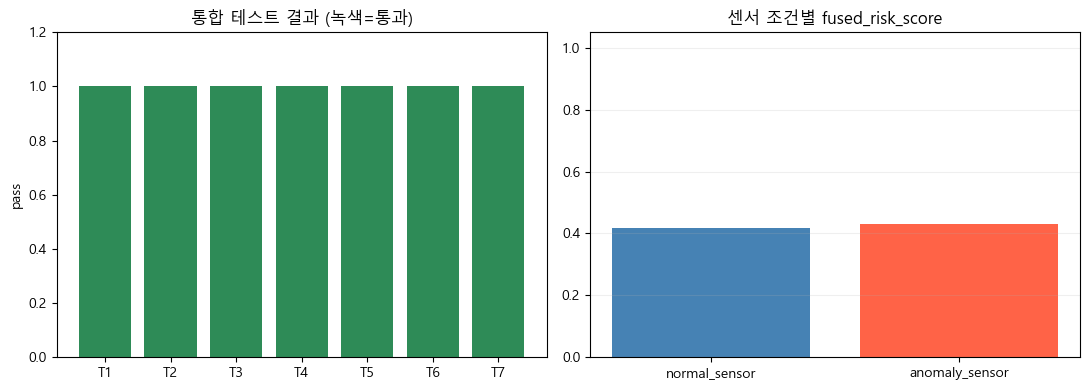

피드백 기준 예측 일치율: 12%


actual_level,HIGH,LOW,MEDIUM
predicted_level,,,
HIGH,0,0,2
LOW,2,1,2
MEDIUM,0,1,0


In [7]:
# 통합 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 테스트 통과/실패
colors = ["seagreen" if p else "tomato" for p in test_df["passed"]]
axes[0].bar(test_df["test_id"], [1] * len(test_df), color=colors)
axes[0].set_title("통합 테스트 결과 (녹색=통과)")
axes[0].set_ylim(0, 1.2)
axes[0].set_ylabel("pass")

# 정상 vs 이상 fused score
cmp = pd.DataFrame([
    {"case": "normal_sensor", "score": sample_resp["ok"]["fusion"]["fused_risk_score"]},
    {"case": "anomaly_sensor", "score": sample_resp["ng"]["fusion"]["fused_risk_score"]},
])
axes[1].bar(cmp["case"], cmp["score"], color=["steelblue", "tomato"])
axes[1].set_title("센서 조건별 fused_risk_score")
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

# 피드백 정확도
if not fb_df.empty:
    acc = fb_df["correct"].mean()
    print(f"피드백 기준 예측 일치율: {acc:.0%}")
    display(fb_df.groupby(["predicted_level", "actual_level"]).size().unstack(fill_value=0))

In [8]:
# 통합 완료 리포트 저장
report = {
    "project": "PCB AOI Visual AI System Integration",
    "completed_at": datetime.now().isoformat(timespec="seconds"),
    "web_service": {
        "health": web_service.health(),
        "endpoints_simulated": ["GET /health", "POST /analyze", "POST /feedback"],
    },
    "integration_tests": {
        "pass_rate": float(pass_rate),
        "results": test_df.to_dict(orient="records"),
    },
    "feedback": {
        "num_records": int(len(fb_df)),
        "accuracy": float(fb_df["correct"].mean()) if len(fb_df) else None,
        "config_after": config.to_dict(),
    },
    "sample_responses": {
        "normal": sample_resp["ok"],
        "anomaly": sample_resp["ng"],
    },
}

with open(OUT_DIR / "integration_completion_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

test_df.to_csv(OUT_DIR / "integration_test_results.csv", index=False, encoding="utf-8-sig")
fb_df.to_csv(OUT_DIR / "feedback_summary.csv", index=False, encoding="utf-8-sig")
config.save(OUT_DIR / "service_config.json")

# FastAPI 배포용 스켈레톤 저장
fastapi_skeleton = '''
# app_main.py (배포용 스케치)
from fastapi import FastAPI
# from modules import VisionModule, SensorModule, FusionService, VisualAIWebService

app = FastAPI(title="PCB AOI Visual AI")
# service = VisualAIWebService(...)

@app.get("/health")
def health():
    return service.health()

@app.post("/analyze")
def analyze(payload: dict):
    # payload: {lot_id, image(list), sensor(list[dict])}
    ...

@app.post("/feedback")
def feedback(payload: dict):
    # payload: {lot_id, predicted_level, actual_level, note}
    ...
'''
(OUT_DIR / "fastapi_skeleton.py").write_text(fastapi_skeleton, encoding="utf-8")

print("저장 완료:")
for fn in [
    "integration_completion_report.json",
    "integration_test_results.csv",
    "feedback_summary.csv",
    "service_config.json",
    "fastapi_skeleton.py",
]:
    print("-", OUT_DIR / fn)

저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\system_integration\integration_completion_report.json
- C:\MyCursorLab\10_프로젝트\outputs\system_integration\integration_test_results.csv
- C:\MyCursorLab\10_프로젝트\outputs\system_integration\feedback_summary.csv
- C:\MyCursorLab\10_프로젝트\outputs\system_integration\service_config.json
- C:\MyCursorLab\10_프로젝트\outputs\system_integration\fastapi_skeleton.py


## 6) 통합 완료 체크리스트

- [x] Vision + Sensor + Fusion 웹 서비스 계층 통합
- [x] `/health`, `/analyze` 계약 검증
- [x] 운영자 피드백 저장 및 설정 반영
- [x] 센서·영상 End-to-End 통합 테스트 (T1~T7)
- [x] 통합 완료 리포트 산출

### FastAPI 실배포 시
1. `outputs/system_integration/fastapi_skeleton.py`를 프로젝트 `app/`로 이동
2. 11·12번 모듈 import
3. `uvicorn app_main:app --reload`로 기동
4. 동일 테스트 케이스를 HTTP 클라이언트로 재실행

---

## 실습 과제

1. 피드백 10건을 추가해 가중치 변화 추이를 그래프로 그리세요.
2. T3 기준을 `fused_score 차이 ≥ 0.05`로 강화해 보세요.
3. `/analyze`에 confidence threshold 파라미터를 추가하세요.
4. Streamlit에서 이미지+센서 CSV 업로드 → 분석 → 피드백 입력 UI를 연결하세요.

---

### 한 줄 정리
시스템 통합은 **API 계약 + 피드백 반영 + 자동 통합 테스트**가 갖춰져야 완료로 볼 수 있습니다.